# Tarea 1: Diseña tu primera metaheurística
### Libreta 01: Introducción a las metaheurísticas

**Metaheurística propuesta: *Tabu-Restart Hill Climbing* (TR-HC).** Mejora el
Ascenso de Colina combinando dos ideas vistas en clase: **reinicios aleatorios**
(de RRHC) y **memoria tabú** (de la Búsqueda Tabú).

La libreta cubre las tres partes pedidas: diseño conceptual, implementación con
visualizaciones y evaluación frente a métodos base.


## Parte 1: Diseño conceptual

### 1.1 El problema

Optimizamos la **función de Rastrigin** en 2D, un banco de pruebas clásico para
metaheurísticas:

$$f(\mathbf{x}) = A\,n + \sum_{i=1}^{n}\left[x_i^2 - A\cos(2\pi x_i)\right], \qquad A=10,\; x_i \in [-5.12, 5.12]$$

Su dificultad representa la de los problemas reales que motivan las
metaheurísticas:

- **Multimodal:** una rejilla regular de **óptimos locales** (uno en cada
  combinación de enteros) que atrapa a los métodos codiciosos.
- **Mínimo global** único en $\mathbf{x}^\* = (0,0)$ con $f(\mathbf{x}^\*) = 0$.
- El término coseno genera un paisaje "rugoso": el gradiente local rara vez
  apunta hacia el óptimo global.

El objetivo es **minimizar** $f$. Veamos el paisaje.


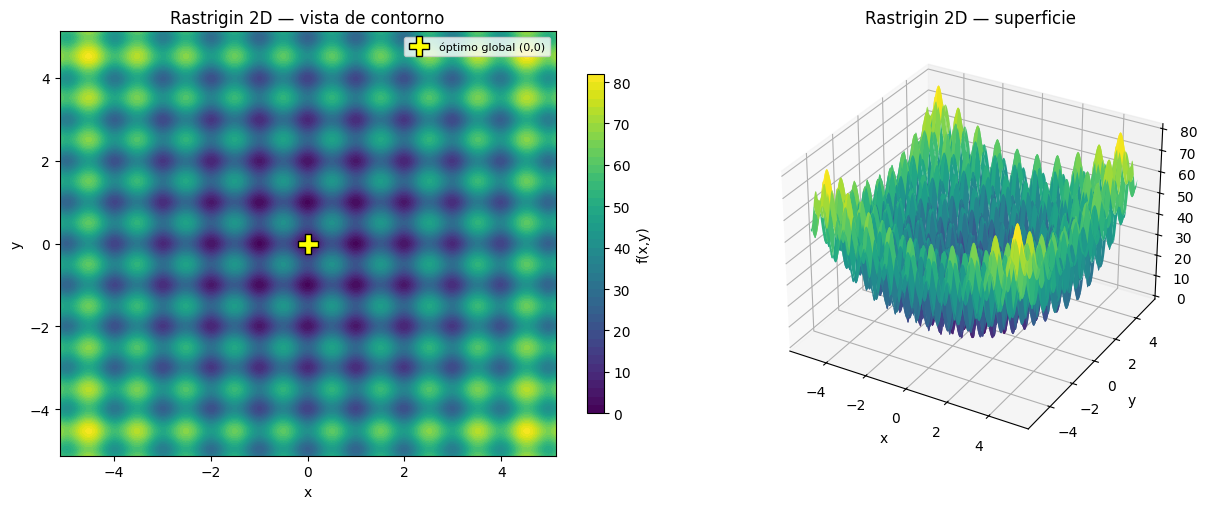

f en el óptimo global (0,0): 0.000
f en un óptimo local (3,-3): 18.000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

LO, HI = -5.12, 5.12

def rastrigin(v, A=10):
    """Función de Rastrigin para un vector v (cualquier dimensión)."""
    v = np.asarray(v, float)
    return A * v.size + np.sum(v**2 - A * np.cos(2 * np.pi * v))

# Malla para visualizar
g = np.linspace(LO, HI, 300)
X, Y = np.meshgrid(g, g)
Z = 20 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))

fig = plt.figure(figsize=(13, 5.2))
ax1 = fig.add_subplot(1, 2, 1)
cf = ax1.contourf(X, Y, Z, levels=40, cmap="viridis")
ax1.plot(0, 0, "P", color="yellow", mec="black", ms=14, label="óptimo global (0,0)")
ax1.set_title("Rastrigin 2D — vista de contorno"); ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.legend(loc="upper right", fontsize=8)
fig.colorbar(cf, ax=ax1, shrink=0.8, label="f(x,y)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Rastrigin 2D — superficie"); ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_zlabel("f")
plt.tight_layout(); plt.show()

print(f"f en el óptimo global (0,0): {rastrigin([0,0]):.3f}")
print(f"f en un óptimo local (3,-3): {rastrigin([3,-3]):.3f}")


### 1.2 La metaheurística: *Tabu-Restart Hill Climbing*

**Punto de partida.** El Ascenso de Colina simple mantiene una sola solución y se
mueve al mejor vecino; en cuanto llega a un óptimo local, se detiene. En un
paisaje multimodal como Rastrigin, queda atrapado en la primera cuenca que toca.
La libreta del curso ya propone una mejora, los **reinicios aleatorios (RRHC)**,
pero esos reinicios son *ciegos*: caen una y otra vez en cuencas ya exploradas y
gastan presupuesto.

**La metáfora.** Un explorador busca el valle más profundo en la niebla con **dos
herramientas**: puede saltar a un punto al azar cuando se queda sin bajada
(reinicio) y lleva un *cuaderno* donde anota cada valle que ya visitó (memoria
tabú). Antes de saltar, consulta el cuaderno y descarta los puntos cercanos a un
valle conocido. Así dirige cada reinicio hacia **territorio nuevo**.

**El mecanismo.** TR-HC envuelve al Ascenso de Colina en un bucle de reinicios
guiados por una lista tabú de cuencas (los óptimos locales ya encontrados):

```text
mejor_global <- vacío;  tabu <- []
mientras queda presupuesto:
    # reinicio DIRIGIDO: punto al azar lejos de toda cuenca tabú
    repetir: x0 <- punto aleatorio   hasta que dist(x0, tabu) > r_tabu
    # ascenso de colina local desde x0
    x_opt <- hill_climbing(x0)        # baja hasta un óptimo local
    tabu.append(x_opt)                # anota la cuenca en el cuaderno
    actualizar mejor_global con x_opt
devolver mejor_global
```

**Balance exploración / explotación.**

- **Explotación:** el ascenso de colina local exprime cada cuenca hasta su fondo.
- **Exploración:** cada reinicio salta a una región lejana y, gracias a la memoria
  tabú, esos saltos cubren cuencas *nuevas* en lugar de repetir las visitadas. Ahí
  está la diferencia entre TR-HC y RRHC.


## Parte 2: Implementación

Definimos un contador de evaluaciones (para comparar los métodos con el **mismo
presupuesto**) y los cuatro algoritmos: Búsqueda Aleatoria, Ascenso de Colina
simple, RRHC (reinicios sin memoria) y TR-HC (la propuesta).


In [2]:
class Objetivo:
    """Envuelve la función objetivo: cuenta evaluaciones y registra el mejor valor
    encontrado hasta cada evaluación (para las curvas de convergencia)."""
    def __init__(self, f, track=False):
        self.f = f; self.n = 0; self.best = np.inf
        self.track = track; self.history = []
    def __call__(self, x):
        v = self.f(x); self.n += 1
        if v < self.best: self.best = v
        if self.track: self.history.append(self.best)
        return v

def hill_climb_local(obj, x0, budget, rng, sigma=0.25, k=10):
    """Ascenso de colina por perturbación gaussiana (best-improvement sobre k
    vecinos). Se detiene en un óptimo local o al agotar el presupuesto."""
    x = np.array(x0, float); fx = obj(x)
    while obj.n < budget:
        mejor_v, mejor_c, mejoro = fx, x, False
        for _ in range(k):
            if obj.n >= budget: break
            c = np.clip(x + rng.normal(0, sigma, 2), LO, HI)
            v = obj(c)
            if v < mejor_v: mejor_v, mejor_c, mejoro = v, c, True
        if mejoro: x, fx = mejor_c, mejor_v
        else: break                      # óptimo local: no hay vecino mejor
    return x, fx

def busqueda_aleatoria(obj, budget, rng):
    bx, bf = None, np.inf
    while obj.n < budget:
        x = rng.uniform(LO, HI, 2); v = obj(x)
        if v < bf: bf, bx = v, x
    return bx, bf

def ascenso_colina(obj, budget, rng):
    """Ascenso de colina simple: un único arranque aleatorio."""
    return hill_climb_local(obj, rng.uniform(LO, HI, 2), budget, rng)

def rrhc(obj, budget, rng):
    """Ascenso de colina con reinicios aleatorios (sin memoria)."""
    bx, bf, optimos = None, np.inf, []
    while obj.n < budget:
        x, fx = hill_climb_local(obj, rng.uniform(LO, HI, 2), budget, rng)
        optimos.append(x)
        if fx < bf: bf, bx = fx, x
    return bx, bf, optimos

def tr_hc(obj, budget, rng, r_tabu=0.7, max_try=30):
    """Tabu-Restart Hill Climbing: reinicios dirigidos por memoria tabú de cuencas."""
    bx, bf, tabu = None, np.inf, []
    while obj.n < budget:
        x0 = None
        for _ in range(max_try):                 # buscar reinicio fuera de cuencas tabú
            c = rng.uniform(LO, HI, 2)
            if all(np.linalg.norm(c - t) > r_tabu for t in tabu):
                x0 = c; break
        if x0 is None: x0 = rng.uniform(LO, HI, 2)
        x, fx = hill_climb_local(obj, x0, budget, rng)
        tabu.append(x)                            # anotar la cuenca encontrada
        if fx < bf: bf, bx = fx, x
    return bx, bf, tabu

print("Algoritmos definidos: busqueda_aleatoria, ascenso_colina, rrhc, tr_hc")


Algoritmos definidos: busqueda_aleatoria, ascenso_colina, rrhc, tr_hc


### 2.1 El aporte de la memoria tabú

Comparamos **RRHC** y **TR-HC** con un presupuesto modesto y dibujamos los óptimos
locales que cada uno encuentra. Con la memoria tabú, TR-HC debería **cubrir más
cuencas distintas** (con menos visitas repetidas) para el mismo presupuesto.


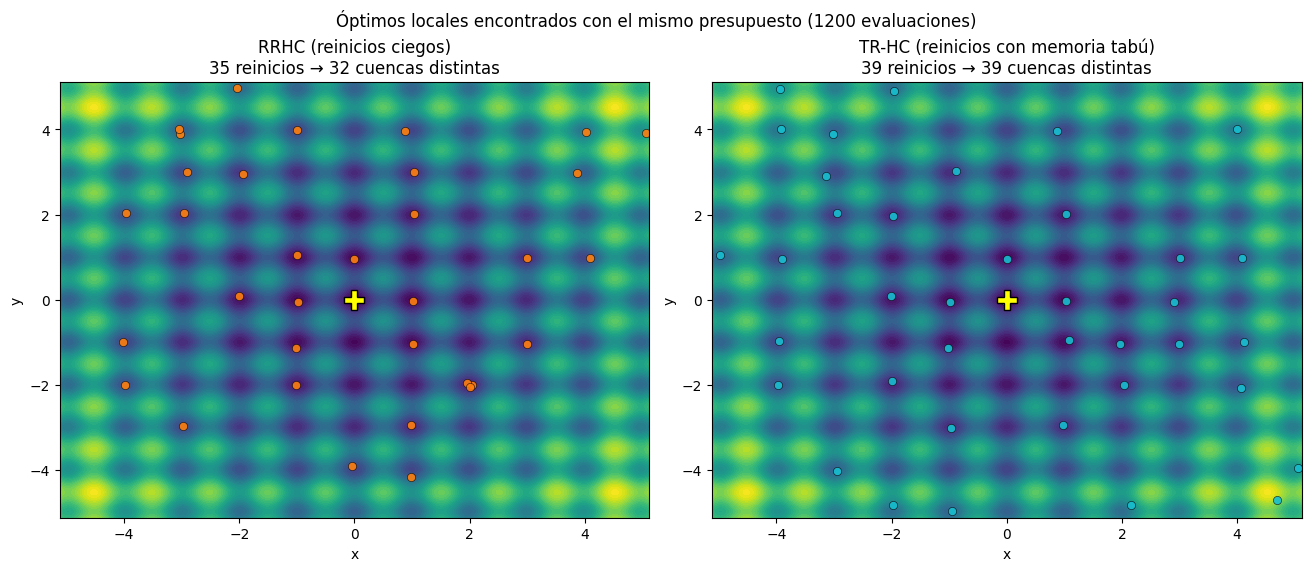

RRHC : 35 reinicios, 32 cuencas distintas
TR-HC: 39 reinicios, 39 cuencas distintas


In [3]:
rng = np.random.default_rng(0)
BUDGET_DEMO = 1200

obj_r = Objetivo(rastrigin)
_, _, opt_rrhc = rrhc(obj_r, BUDGET_DEMO, np.random.default_rng(0))
obj_t = Objetivo(rastrigin)
_, _, opt_trhc = tr_hc(obj_t, BUDGET_DEMO, np.random.default_rng(0))

def cuencas_unicas(optimos):
    return len({(round(o[0]), round(o[1])) for o in optimos})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), constrained_layout=True)
for ax, optimos, titulo, color in [
    (axes[0], opt_rrhc, "RRHC (reinicios ciegos)", "tab:orange"),
    (axes[1], opt_trhc, "TR-HC (reinicios con memoria tabú)", "tab:cyan"),
]:
    ax.contourf(X, Y, Z, levels=40, cmap="viridis")
    O = np.array(optimos)
    ax.scatter(O[:, 0], O[:, 1], s=35, color=color, ec="black", lw=0.4, alpha=0.9)
    ax.plot(0, 0, "P", color="yellow", mec="black", ms=14)
    ax.set_title(f"{titulo}\n{len(optimos)} reinicios → {cuencas_unicas(optimos)} cuencas distintas")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.suptitle(f"Óptimos locales encontrados con el mismo presupuesto ({BUDGET_DEMO} evaluaciones)", fontsize=12)
plt.show()

print(f"RRHC : {len(opt_rrhc)} reinicios, {cuencas_unicas(opt_rrhc)} cuencas distintas")
print(f"TR-HC: {len(opt_trhc)} reinicios, {cuencas_unicas(opt_trhc)} cuencas distintas")


## Parte 3: Evaluación

**Protocolo experimental.** Ejecuto cada método **30 veces** (semillas distintas)
con un presupuesto fijo de **4000 evaluaciones** de $f$. Mido:

- **Calidad:** valor final de $f$ (media ± desviación, y el mejor de las 30).
- **Tasa de éxito:** fracción de corridas con $f < 1$ (dentro de la cuenca global).
- **Tiempo** medio de ejecución por corrida.

El presupuesto fijo en evaluaciones da la comparación justa: cuenta cuántas veces
se consulta la función objetivo, no el tiempo de reloj (en problemas reales, cada
evaluación es lo costoso).


In [4]:
import time
import pandas as pd
from IPython.display import display

BUDGET, R = 4000, 30

def correr(metodo, budget, seed, track=False):
    rng = np.random.default_rng(seed)
    obj = Objetivo(rastrigin, track=track)
    res = metodo(obj, budget, rng)
    bf = res[1]
    return bf, obj

metodos = {
    "Búsqueda Aleatoria": busqueda_aleatoria,
    "Ascenso de Colina":  ascenso_colina,
    "RRHC":               rrhc,
    "TR-HC (propuesta)":  tr_hc,
}

filas = []
curvas = {}
for nombre, fn in metodos.items():
    fs = []
    t0 = time.perf_counter()
    for s in range(R):
        bf, _ = correr(fn, BUDGET, s)
        fs.append(bf)
    t_ms = (time.perf_counter() - t0) / R * 1000
    fs = np.array(fs)
    # curvas de convergencia (best-so-far por evaluación, promediado sobre R)
    hs = []
    for s in range(R):
        _, obj = correr(fn, BUDGET, s, track=True)
        h = np.array(obj.history)
        if len(h) < BUDGET:                      # rellenar si terminó antes (HC simple)
            h = np.concatenate([h, np.full(BUDGET - len(h), h[-1])])
        hs.append(h[:BUDGET])
    curvas[nombre] = np.mean(hs, axis=0)
    filas.append({
        "Método": nombre,
        "f medio": fs.mean(),
        "f std": fs.std(),
        "mejor f": fs.min(),
        "éxito (f<1)": f"{np.mean(fs < 1)*100:.0f}%",
        "tiempo (ms)": t_ms,
    })

tabla = pd.DataFrame(filas).set_index("Método")
display(tabla.round(3))


,f medio,f std,mejor f,éxito (f<1),tiempo (ms)
Método,,,,,
Búsqueda Aleatoria,0.936,0.504,0.071,53%,42.601
Ascenso de Colina,16.883,9.173,2.591,0%,0.598
RRHC,0.809,0.550,0.028,53%,55.046
TR-HC (propuesta),0.596,0.414,0.031,77%,180.033


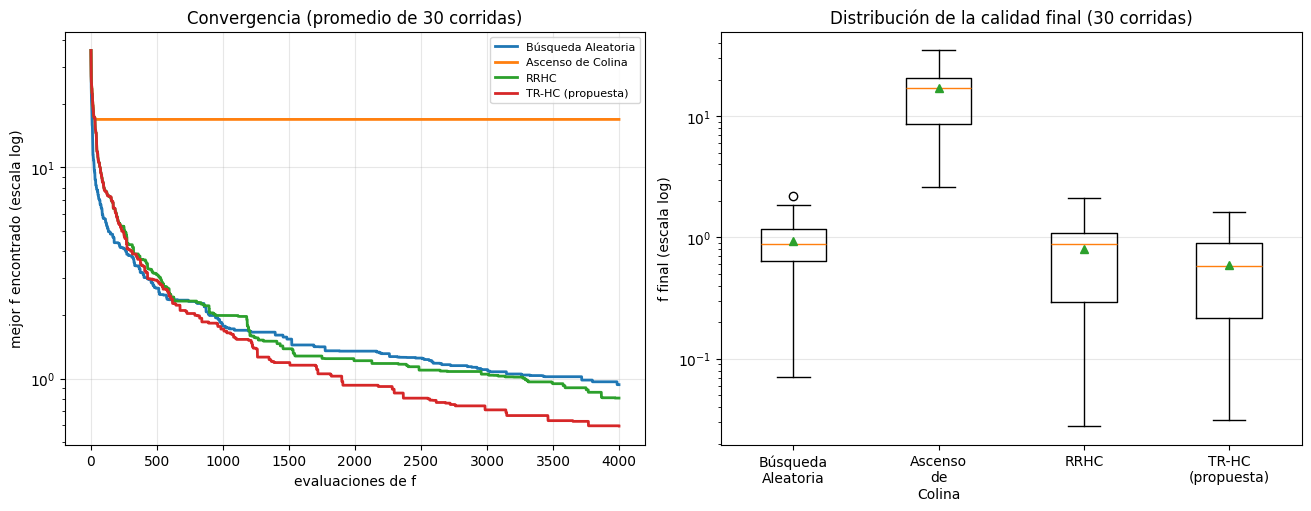

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# (a) Curvas de convergencia
ax = axes[0]
for nombre, curva in curvas.items():
    ax.plot(np.arange(1, BUDGET + 1), curva, label=nombre, lw=2)
ax.set_yscale("log")
ax.set_xlabel("evaluaciones de f"); ax.set_ylabel("mejor f encontrado (escala log)")
ax.set_title("Convergencia (promedio de 30 corridas)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) Distribución de la calidad final
ax = axes[1]
datos = []
for nombre, fn in metodos.items():
    datos.append([correr(fn, BUDGET, s)[0] for s in range(R)])
ax.boxplot(datos, showmeans=True)
ax.set_xticks(range(1, len(metodos) + 1))
ax.set_xticklabels([m.replace(" ", "\n") for m in metodos])
ax.set_yscale("log")
ax.set_ylabel("f final (escala log)")
ax.set_title("Distribución de la calidad final (30 corridas)")
ax.grid(alpha=0.3, axis="y")
plt.show()


### Análisis de fortalezas y debilidades

**Lectura de los resultados.**

- El **Ascenso de Colina simple** queda último por amplio margen: un solo arranque
  lo deja atrapado en un óptimo local (tasa de éxito 0 %). Es el más rápido, pero
  desperdicia el presupuesto, porque tras atascarse ya no avanza.
- La **Búsqueda Aleatoria** rinde bien en 2D (el espacio es pequeño y 4000 muestras
  lo cubren), aunque su calidad media y su tasa de éxito se quedan cortas: no
  refina las buenas soluciones.
- **RRHC** supera a la búsqueda aleatoria al exprimir cada cuenca con ascenso
  local, pero sus reinicios ciegos repiten cuencas y gastan evaluaciones.
- **TR-HC** logra la **mejor calidad media y la mayor tasa de éxito**. Con la
  memoria tabú, los reinicios cubren más cuencas distintas para el mismo
  presupuesto, así que el algoritmo da con la cuenca global más a menudo.

**Fortalezas de TR-HC.**

- Junta explotación (ascenso local) y exploración sistemática (reinicios y tabú).
- No necesita gradiente; solo evalúa $f$.
- Su ventaja sobre RRHC sale de un único cambio aislado, la memoria tabú, lo que
  vuelve la mejora fácil de atribuir.

**Debilidades y límites.**

- El radio tabú `r_tabu` es sensible al problema: si es grande, rechaza demasiados
  reinicios; si es pequeño, no evita repeticiones.
- La lista tabú crece y el chequeo de distancia cuesta $O(\text{nº de cuencas})$
  por reinicio, de ahí su mayor tiempo de reloj.
- En **dimensión alta** el número de cuencas crece de forma exponencial y "cubrir
  cuencas nuevas" deja de ser viable; ahí rinden mejor los métodos poblacionales.

**Conclusión.** Con un cambio acotado, la memoria tabú de cuencas sobre el esquema
de reinicios, TR-HC supera a sus predecesores en Rastrigin. El resultado refuerza
el principio central del curso: lo que vuelve útil a una metaheurística es el
balance entre exploración y explotación que ajusta a la estructura del problema.
